**NOTE: Bolides 2, 8, 12, 13, and 14 have been removed from calculation due to the data quality.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #read in the data as a pandas dataframe

In [3]:
len(bd)

315

In [4]:
def findtheta(lat, long, alt): #kept here but not actually used in calculations
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom (lat1, long1, lat2, long2, r= 6371000): #haversine equation converts change in latitude/longitude to a distance in meters
    lat1rad = np.radians(lat1) #conversion to radians since our measurements are in degrees
    long1rad = np.radians(long1)
    lat2rad = np.radians(lat2)
    long2rad = np.radians(long2)
    dlat = lat2rad - lat1rad #the difference in latitude
    dlong = long2rad - long1rad #the difference in longitude

    a= np.sin(dlat/2)**2 + np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2 #direct calculation broken into parts
    b= 2*np.arcsin(np.sqrt(a))

    #uncertainty estimation on degtom, each of these 4 lines is representitive of a partial derivitave with respect to that variable 
    errorla1= -r*2*(np.sin(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.cos(dlat/2)*np.sin(dlat/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorla2= r*2*(np.cos(dlat/2)*np.sin(dlat/2)-np.cos(lat1rad)*np.sin(lat2rad)*np.sin(dlong/2)**2)/(np.sqrt(1-(np.sin(dlat/2)**2+np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2)**2))
    errorlo1= -r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    errorlo2= r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
    #this is the errors added in quadrature 
    errordegtom= np.sqrt((errorla1)**2*errorlat**2+(errorla2)**2*errorlat**2+(errorlo1)**2*errorlong**2+(errorlo2)**2*errorlong**2)
    
    
    return r*b, errordegtom

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
    rho0= 1.225 #kg/m^3                   #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [5]:
isinstance(bd.iloc[4]['lat_stereo_g16'], float)

False

In [6]:
#indexlist= [12, 52, 71, 85, 105, 115, 147, 175, 265, 310] #the index of the bolides being analyzed within bd
#satellite= ['g16', 'g16', 'g17', 'g17', 'g17', 'g17', 'g16', 'g16', 'g18', 'g17'] #the satellites each bolide was observed by
rockyradii= [] #empty lists of values we want to find
errorrocky= []
icyradii= []
erroricy= []
metalradii= []
errormetal= []
ilist= []

for i in range(len(bd)): #for every bolide we want to analyze...
    
    if isinstance(bd.iloc[i]['lat_stereo_g16'], float) == True:
        pass
    else:
        lat= literal_eval(bd.iloc[i]['lat_stereo_g16']) #reads the latitude value for this bolide
        long= literal_eval(bd.iloc[i]['lon_stereo_g16']) #reads the longitude value
        alt= np.array(literal_eval(bd.iloc[i]['alt_stereo_g16']))*1000 #convert the altitude values to meters 
        energy = literal_eval(bd.iloc[i]['energyJoules_stereo_g16']) #the energy curve from each bolide

        errorlat= 5000 #5 km error for latitude and longitude (Jenniskens, 2018)
        errorlong= 5000
        erroralt= literal_eval(bd.iloc[i]['residual_dist_stereo_g16']) #the error on the altitude is a variable in bd
    
        for e in range(len(energy)):
            if energy[e] == np.max(energy):
                imaxenergy=e #determine the index at which the bolide catastrophically destructs

        totalmass= 0 #these will increase as we sum the steos of our calculation
        totalerror= 0

        for u in range (imaxenergy): #until the bolide catastrophically destructs...
            deltalatlong = np.abs(degtom(lat[u], long[u], lat[u+1], long[u+1]))[0] #calculate the distance in meters for each step in latitude/longitude
    
            errordeltalatlong= degtom(lat[u], long[u], lat[u+1], long[u+1])[1]
    
            deltaalt = np.abs(alt[u+1]-alt[u]) #the change in altitude for each step 
    
            erroralt1= (alt[u]-alt[u+1])/np.abs(alt[u+1]-alt[u]) #partial derivative for error calculation
            erroralt2= (alt[u+1]-alt[u])/np.abs(alt[u]-alt[u+1])
            errordalt= np.sqrt((erroralt1)**2*(erroralt[u])**2+(erroralt2)**2*(erroralt[u+1])**2) #deltaalt errors added in quadrature 
    
            h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
            errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) #the error value for h

            altm = (1/2)*(alt[u]+alt[u+1]) #midpoint altitude for calculating air density
    
            rho = airrho(altm) #air density

            erroraltm= .5*np.sqrt(erroralt[u]**2+erroralt[u+1]**2)
            errorrho= (rho/8500)*erroraltm #the uncertainty on air density

            totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

            terho= (errorrho/rho)**2 
            teh= (errorh/h)**2
            totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder
    
        rockyradii.append((3/4)*(totalmass/rockyrho)*100) #+- totalerror #units of cm
        metalradii.append((3/4)*(totalmass/metalrho)*100)
        icyradii.append((3/4)*(totalmass/icyrho)*100)

        errorrocky.append((3/4)*(np.sqrt(totalerror)/rockyrho)*100) #uncertainty estimation for each potential bolide
        errormetal.append((3/4)*(np.sqrt(totalerror)/metalrho)*100)
        erroricy.append((3/4)*(np.sqrt(totalerror)/icyrho)*100)
        ilist.append(i)
        
       

#create a dictionary that can be made into a pandas dataframe
b= {'Index in bolide_data' : ilist, 'Satellite' : 'G16', 'Rocky Bolide Radii' : rockyradii, 'Rocky Bolide Uncertainty' : errorrocky, 'Metal Bolide Radii' : metalradii, 'Metal Bolide Uncertainty' : errormetal, 'Icy Bolide Radii' : icyradii, 'Icy Bolide Uncertainty' : erroricy}
bolide = pd.DataFrame(data=b) #dataframe of all the results

C:\Users\under\AppData\Local\Temp\ipykernel_3004\2934162483.py:39: RuntimeWarning: invalid value encountered in scalar divide
  erroralt1= (alt[u]-alt[u+1])/np.abs(alt[u+1]-alt[u]) #partial derivative for error calculation
C:\Users\under\AppData\Local\Temp\ipykernel_3004\2934162483.py:40: RuntimeWarning: invalid value encountered in scalar divide
  erroralt2= (alt[u+1]-alt[u])/np.abs(alt[u]-alt[u+1])
C:\Users\under\AppData\Local\Temp\ipykernel_3004\2934162483.py:45: RuntimeWarning: invalid value encountered in scalar divide
  errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) #the error value for h


In [7]:
bolide

,Index in bolide_data,Satellite,Rocky Bolide Radii,Rocky Bolide Uncertainty,Metal Bolide Radii,Metal Bolide Uncertainty,Icy Bolide Radii,Icy Bolide Uncertainty
0,4,G16,0.001553,1.262829,0.000725,0.589320,0.007247,5.893201e+00
1,12,G16,0.003861,6.716742,0.001802,3.134479,0.018017,3.134479e+01
2,13,G16,0.013796,7.740876,0.006438,3.612409,0.064381,3.612409e+01
3,17,G16,0.012583,17.810629,0.005872,8.311627,0.058720,8.311627e+01
4,19,G16,0.016386,44.192495,0.007647,20.623164,0.076466,2.062316e+02
...,...,...,...,...,...,...,...,...
91,287,G16,0.010151,20.977078,0.004737,9.789303,0.047371,9.789303e+01
92,298,G16,207.463488,551363.246512,96.816294,257302.848372,968.162942,2.573028e+06
93,307,G16,199.890598,264468.024219,93.282279,123418.411302,932.822789,1.234184e+06
94,310,G16,0.000337,0.862459,0.000157,0.402481,0.001573,4.024809e+00


In [8]:
len(bolide)

96

**GRAPHS**

Text(0.5, 0, 'Bolide Number')

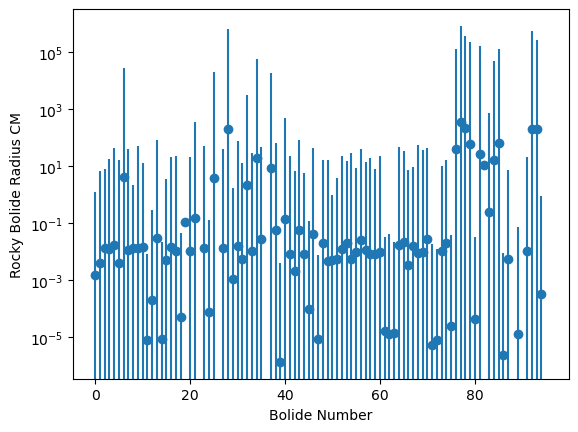

In [9]:
plt.scatter(range(len(bolide['Rocky Bolide Radii'])), bolide['Rocky Bolide Radii'])
plt.errorbar(range(len(bolide['Rocky Bolide Radii'])), bolide['Rocky Bolide Radii'], yerr=bolide['Rocky Bolide Uncertainty'], linestyle='none')
plt.ylabel('Rocky Bolide Radius CM')
# plt.ylim(0)
plt.yscale('log')
plt.xlabel('Bolide Number')

(array([88.,  3.,  0.,  0.,  0.,  2.,  2.,  0.,  0.,  1.]),
 array([  0.        ,  34.40314488,  68.80628977, 103.20943465,
        137.61257954, 172.01572442, 206.41886931, 240.82201419,
        275.22515908, 309.62830396, 344.03144885]),
 <BarContainer object of 10 artists>)

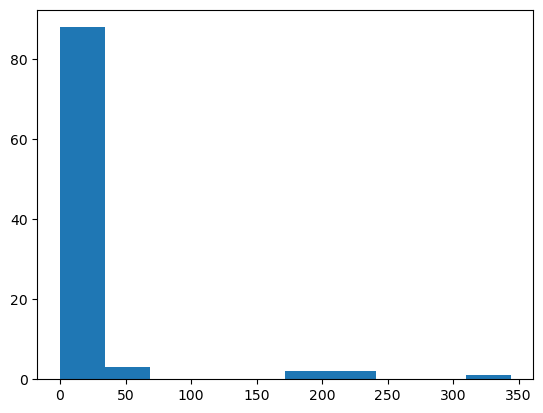

In [10]:
plt.hist(bolide['Rocky Bolide Radii'])

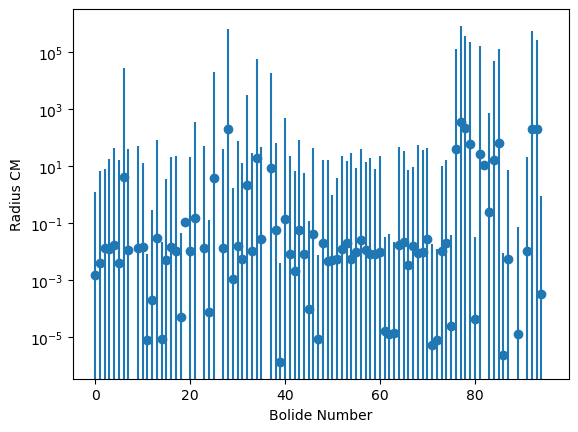

In [11]:
plt.scatter(range(len(bolide['Rocky Bolide Radii'][:8])), bolide['Rocky Bolide Radii'][:8]) #second graph removing the outlier bolide
plt.scatter(range(len(bolide['Rocky Bolide Radii']))[9:], bolide['Rocky Bolide Radii'][9:], c='C0')
plt.errorbar(range(len(bolide['Rocky Bolide Radii'][:8])), bolide['Rocky Bolide Radii'][:8], yerr=bolide['Rocky Bolide Uncertainty'][:8], linestyle='none')
plt.errorbar(range(len(bolide['Rocky Bolide Radii']))[9:], bolide['Rocky Bolide Radii'][9:], yerr=bolide['Rocky Bolide Uncertainty'][9:], c='C0', linestyle='none')
plt.ylabel('Radius CM')
plt.xlabel('Bolide Number')
plt.yscale('log') #the same plot but with the outlier bolide removed

In [12]:
class Bolide:


    def degtom (lat1, long1, lat2, long2, r= 6371000): #haversine equation converts change in latitude/longitude to a distance in meters
        lat1rad = np.radians(lat1) #conversion to radians since our measurements are in degrees
        long1rad = np.radians(long1)
        lat2rad = np.radians(lat2)
        long2rad = np.radians(long2)
        dlat = lat2rad - lat1rad #the difference in latitude
        dlong = long2rad - long1rad #the difference in longitude

        a= np.sin(dlat/2)**2 + np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2 #direct calculation broken into parts
        b= 2*np.arcsin(np.sqrt(a))

        #uncertainty estimation on degtom, each of these 4 lines is representitive of a partial derivitave with respect to that variable 
        errorla1= -r*2*(np.sin(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.cos(dlat/2)*np.sin(dlat/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
        errorla2= r*2*(np.cos(dlat/2)*np.sin(dlat/2)-np.cos(lat1rad)*np.sin(lat2rad)*np.sin(dlong/2)**2)/(np.sqrt(1-(np.sin(dlat/2)**2+np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2)**2))
        errorlo1= -r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
        errorlo2= r*2*(np.cos(lat1rad)*np.cos(lat2rad)*np.cos(dlong/2)*np.sin(dlong/2))/(np.sqrt(1-(np.cos(lat1rad)*np.cos(lat2rad)*np.sin(dlong/2)**2+np.sin(dlat/2)**2)**2))
        #this is the errors added in quadrature 
        errordegtom= np.sqrt((errorla1)**2*errorlat**2+(errorla2)**2*errorlat**2+(errorlo1)**2*errorlong**2+(errorlo2)**2*errorlong**2)
    
    
        return r*b, errordegtom

    def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
        rho0= 1.225 #kg/m^3                   #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
        return (rho0*(1/(np.e**(z/H))))
    
    def radii(dataframe, index, satellite):
        rockyrho = 3500 #kg/m^3
        metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
        icyrho = 750 #kg/m^3
        
        bd= pd.read_csv(dataframe)
        rockyradii= [] #empty lists of values we want to find
        errorrocky= []
        icyradii= []
        erroricy= []
        metalradii= []
        errormetal= []
        ilist= []            

        for i in range(len(index)): #for every bolide we want to analyze...
            if isinstance(bd.iloc[index[i]][f'lat_stereo_{satellite}'], float) == True:
                print('A')
                pass
            else:
                lat= literal_eval(bd.iloc[index[i]][f'lat_stereo_{satellite}']) #reads the latitude value for this bolide
                long= literal_eval(bd.iloc[index[i]][f'lon_stereo_{satellite}']) #reads the longitude value
                alt= np.array(literal_eval(bd.iloc[index[i]][f'alt_stereo_{satellite}']))*1000 #convert the altitude values to meters 
                energy = literal_eval(bd.iloc[index[i]][f'energyJoules_stereo_{satellite}']) #the energy curve from each bolide

                errorlat= 4000 #we're estimating that the error on latitude and longitude measurements are half a pixel, or 4000 meters
                errorlong= 4000
                erroralt= literal_eval(bd.iloc[index[i]][f'residual_dist_stereo_{satellite}']) #the error on the altitude is a variable in bd
        
                for e in range(len(energy)):
                    if energy[e] == np.max(energy):
                        imaxenergy=e #determine the index at which the bolide catastrophically destructs

                totalmass= 0 #these will increase as we sum the steos of our calculation
                totalerror= 0

                for u in range (imaxenergy): #until the bolide catastrophically destructs...
                    deltalatlong = np.abs(degtom(lat[u], long[u], lat[u+1], long[u+1]))[0] #calculate the distance in meters for each step in latitude/longitude
    
                    errordeltalatlong= degtom(lat[u], long[u], lat[u+1], long[u+1])[1]
    
                    deltaalt = np.abs(alt[u+1]-alt[u]) #the change in altitude for each step 
    
                    erroralt1= (alt[u]-alt[u+1])/np.abs(alt[u+1]-alt[u]) #partial derivative for error calculation
                    erroralt2= (alt[u+1]-alt[u])/np.abs(alt[u]-alt[u+1])
                    errordalt= np.sqrt((erroralt1)**2*(erroralt[u])**2+(erroralt2)**2*(erroralt[u+1])**2) #deltaalt errors added in quadrature 
    
                    h= np.sqrt(deltalatlong**2 + deltaalt**2) #pythagorean theorum the change in latitude, longitude, and altitude
    
                    errorh= np.sqrt((deltalatlong/h)**2*(errordeltalatlong)**2+(deltaalt/h)**2*(errordalt)**2) #the error value for h

                    altm = (1/2)*(alt[u]+alt[u+1]) #midpoint altitude for calculating air density
    
                    rho = airrho(altm) #air density

                    erroraltm= .5*np.sqrt(erroralt[u]**2+erroralt[u+1]**2)
                    errorrho= (rho/8500)*erroraltm #the uncertainty on air density

                    totalmass = totalmass+(h*rho) #sum up the total mass for each cylinder

                    terho= (errorrho/rho)**2 
                    teh= (errorh/h)**2
                    totalerror= totalerror+(h*rho*(np.sqrt(terho+teh)))**2 #and the total error for each cylinder
    
                rockyradii.append((3/4)*(totalmass/rockyrho)*100) #+- totalerror #units of cm
                metalradii.append((3/4)*(totalmass/metalrho)*100)
                icyradii.append((3/4)*(totalmass/icyrho)*100)

                errorrocky.append((3/4)*(np.sqrt(totalerror)/rockyrho)*100) #uncertainty estimation for each potential bolide
                errormetal.append((3/4)*(np.sqrt(totalerror)/metalrho)*100)
                erroricy.append((3/4)*(np.sqrt(totalerror)/icyrho)*100)
                ilist.append(index[i])
       

    #create a dictionary that can be made into a pandas dataframe
            if len(index) == 1:
                dict= {f'Index in {dataframe}' : ilist[0], 'Satellite' : f'{satellite}', 'Rocky Bolide Radii' : rockyradii, 'Rocky Bolide Uncertainty' : errorrocky, 'Metal Bolide Radii' : metalradii, 'Metal Bolide Uncertainty' : errormetal, 'Icy Bolide Radii' : icyradii, 'Icy Bolide Uncertainty' : erroricy}
            else:
                dict= {f'Index in {dataframe}' : ilist, 'Satellite' : f'{satellite}', 'Rocky Bolide Radii' : rockyradii, 'Rocky Bolide Uncertainty' : errorrocky, 'Metal Bolide Radii' : metalradii, 'Metal Bolide Uncertainty' : errormetal, 'Icy Bolide Radii' : icyradii, 'Icy Bolide Uncertainty' : erroricy}
            bdict = pd.DataFrame(data=dict) #dataframe of all the results
            return (bdict)

In [13]:
b= Bolide

In [14]:
b.radii('datafixed_bolide_data.csv', [12, 15], "g16")

,Index in datafixed_bolide_data.csv,Satellite,Rocky Bolide Radii,Rocky Bolide Uncertainty,Metal Bolide Radii,Metal Bolide Uncertainty,Icy Bolide Radii,Icy Bolide Uncertainty
0,12,g16,0.003861,6.716742,0.001802,3.134479,0.018017,31.344794
